# Exemplo 1: Clustering Hierárquico com Scikit-learn

**Nota**: O método hierárquico aglomerativo segue uma abordagem bottom-up (de baixo para cima), onde:
- Cada ponto começa como um cluster individual;
- A cada iteração, os dois clusters mais próximos são fundidos;
- O processo continua até atingir o número de clusters desejado ou formar um único grande cluster.

In [31]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

import pandas as pd

In [32]:
# Carregar dados do conjunto Iris
iris = load_iris()
data = iris.data
labels_true = iris.target

In [33]:
# Criar modelo de clustering hierárquico
# n_clusters: número de grupos a formar
# linkage = 'ward': método de ligação baseado em variância mínima

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_pred = model.fit_predict(data)

In [34]:
# Comparar com classes reais
pd.crosstab(labels_pred, labels_true)

col_0,0,1,2
row_0,,,
0,0,49,15
1,50,0,0
2,0,1,35


**Explicação**
- AgglomerativeClustering executa um método bottom-up de agrupamento.
- n_clusters = 3: define o número de grupos finais desejados.
- linkage = 'ward?: minimiza a variância total dentro de cada cluster.
- A tabela cruzada ajuda a avaliar visualmente a correspondência entre os clusters e as classes verdadeiras do dataset.

---

# Exemplo 2: K-Means no Irís

**Nota**:

Este exemplo reutiliza os dados carregados no Exemplo 1.

Se estiveres a executar este bloco de forma isolada, certifica-te de que os dados estão carregados com:

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

iris = load_iris()
data = iris.data

In [36]:
# Criar modelo K-Means
# n_clusters: número de clusters desejado
# random_state: controla a aleatoriedade da inicialização

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data)


In [37]:
# Mostrar centróides
print("Centróides dos clusters:")
print(kmeans.cluster_centers_)

Centróides dos clusters:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [38]:
# Avaliar com coeficiente de silhueta
sil_score = silhouette_score(data, labels_kmeans)
print(f"Coeficiente de silhueta: {sil_score:.2f}")

Coeficiente de silhueta: 0.55


**Explicação**:
- n_clusters = 3: especifica o número de grupos.
- fit_predict: ajusta o modelo e obtèm as etiquetas dos clusters.
- clusters_centers_: devolve as coordenadas dos centróides.
- silhouette_score: mede quão bem separados estão os clustes (varia entre -1 e 1)

---

# Exemplo 3: Viasualização com PCA

**Nota**: Este exemplo pressupõe que os dados (data) e os rótulos dos clusters (labels_kmeans) foram gerados preciamente, como no exemplo 2.

In [39]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
data = iris.data

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data)


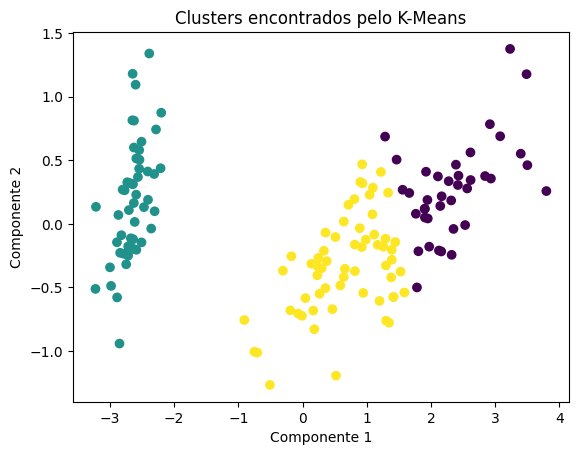

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Redução de dimensionalidade para visualização
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

# Visualizar clusters do K_Means
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('Clusters encontrados pelo K-Means')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

**Explicação**:
- PCA reduz as 4 dimensões do Irís para 2 componentes principais.
- Permite visualizar os agrupamentos de forma mais intuitiva.
As cores representam os clusters encontrados.

---

# Exemplo 4: DBSCAN com Dataset Irís (2 features para visualização)

In [41]:
from sklearn.datasets import load_iris 
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [42]:
# Carregar e preparar os dados 
iris = load_iris()
data = iris.data[:, :2] # Usar apenas 2 features para visualização 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [43]:
# Aplicar DBSCAN
# eps: raio da vizinhança
# min_samples: número mínimo de pontos para formar um cluster 
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(data_scaled)

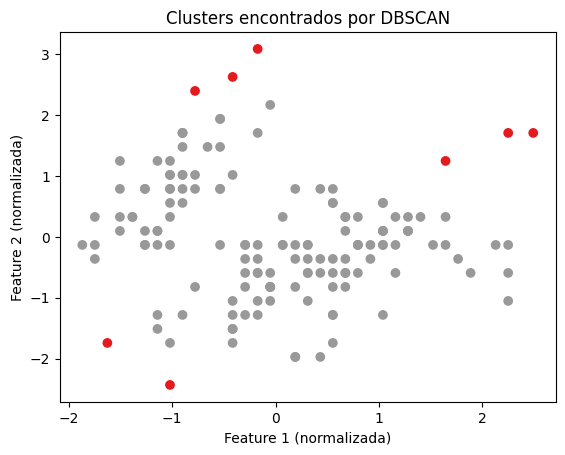

In [44]:
# Visualizar os clusters 
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_db, cmap='Set1') 
plt.title("Clusters encontrados por DBSCAN")
plt.xlabel("Feature 1 (normalizada)")
plt.ylabel("Feature 2 (normalizada)")
plt.show()

In [45]:
# Mostrar etiquetas encontradas
print("Etiquetas encontradas pelo DBSCAN:")
print(set(labels_db))

Etiquetas encontradas pelo DBSCAN:
{np.int64(0), np.int64(-1)}


**Explicação**:
`eps` controla o raio de vizinhança e `min_samples` o mínimo de pontos para formar uma região densa. O rótulo `-1`indica pontos classificafos como ruído. 

---

# Exemplo 5: Gaussian Mixture Model (GMM) no Dataset Iris

In [46]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import load_iris

In [47]:
# Carregar dados 
iris = load_iris()
X = iris.data
true_labels = iris.target 

In [48]:
# Ajustar modelo GMM 
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
pred_labels = gmm.predict(X)

In [49]:
# Avaliação com índice Rand ajustado 
ari = adjusted_rand_score(true_labels, pred_labels)
print(f"Adjusted Rand Index (ARI): {ari:.2f}")

Adjusted Rand Index (ARI): 0.90


**Explicação**: O GMM modela clusters como distribuições normais. O `ARI` avalia a sobreposição entre os clusters encontrados e as classes reais.

---

# Exemplo 6: Explorar DBSCAN com diferentes valores de eps

In [50]:
from sklearn.datasets import load_iris 
from sklearn.cluster import DBSCAN 
from sklearn.preprocessing import StandardScaler

In [51]:
# Carregar e preparar os dados
iris = load_iris() 
data = iris.data[:, :2] # Usar apenas duas features 
scaler = StandardScaler() 
data_scaled = scaler.fit_transform(data)

In [52]:
# Testar diferentes valores de eps
for eps_val in [0.3, 0.5, 0.7]:
    dbsacn = DBSCAN(eps=eps_val, min_samples=5)
    labels = dbsacn.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val}: clusters encontrados = {n_clusters}")

eps=0.3: clusters encontrados = 2
eps=0.5: clusters encontrados = 1
eps=0.7: clusters encontrados = 1


**Explicação**:
- eps define o raio da vizinhança local para cada ponto.
- min_samples=5: mínimo de pontos para formar um cluster denso.
- O número de clusters encontrados muda com eps, afetando a sensibilidade a ruído e a separação de grupos.

---

# Exemplo 7: GMM aplicado a dados sintéticos

In [53]:
from sklearn.datasets import make_blobs 
from sklearn.mixture import GaussianMixture 

import matplotlib.pyplot as plt

In [54]:
# Gerar dados sintéticos gaussianos

X_synth, y_synth = make_blobs(
    n_samples=300, # número total de amostras 
    centers=3, # número de clusters 
    cluster_std=0.60, # dispersão dos clusters 
    random_state=42 # reprodutibilidade 
)

In [55]:
# Criar e ajustar modelo GMM
gmm_synth = GaussianMixture(n_components=3, random_state=42) 
gmm_synth.fit(X_synth)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [56]:
# Obter previsões dos clusters 
y_pred = gmm_synth.predict(X_synth)

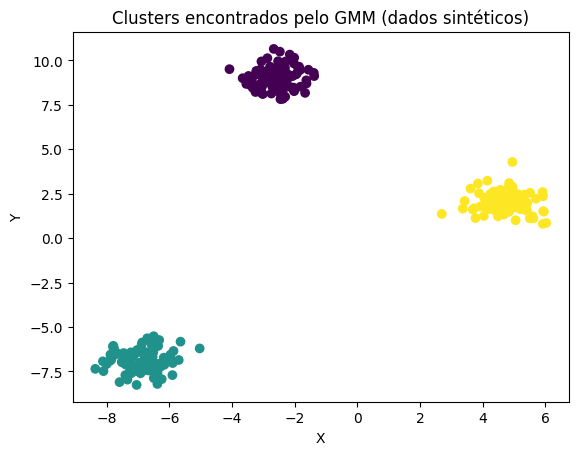

In [57]:
# Visualizar resultados 
plt.scatter(X_synth[:, 0], X_synth[:, 1], c=y_pred, cmap='viridis')
plt.title("Clusters encontrados pelo GMM (dados sintéticos)") 
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Explicação**: Este exemplo mostra como o GMM consegue identificar clusters com forma e densidade semelhantes às gaussianas, sendo ideal para dados com estas características.

NOTA: Dados sintéticos são conjuntos de dados artificiais, ou seja, gerados manualmente ou por algoritmos, em vez de serem recolhidos do mundo real. São amplamente utilizados para fins de:
- Teste e desenvolvimento de algoritmos;
- Simulação de cenários controlados;
- Validação de modelos em ambiente seguro e previsível.

Por que usar dados sintéticos?
1. Permitem controlar totalmente a estrutura dos dados (ex.: número de clusters, dispersão, dimensões).
1. Facilitam a visualização e compreensão de algoritmos de aprendizagem.
1. Evita problemas legais ou de privacidade, já que não envolvem dados reais de pessoas.


---

# Exemplo 8: Clustering com Dataset do Kaggle – Wine Quality

Neste exemplo, utilizamos um dataset real retirado do Kaggle: o Wine Quality Dataset, que contém atributos físico-químicos de vinhos e a sua qualidade sensorial avaliada por especialistas.

Fonte do dataset: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [58]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

In [59]:
# Carregar dataset local (assumindo que está em CSV na mesma pasta)
# Tentar carregar o dataset com verificação

df = pd.read_csv("data/winequality-red.csv")

In [60]:
# Pré-processamento: normalização
# Utilizamos todas as colunas exceto 'quality' como variáveis preditoras

features = df.columns[:-1] # todas as colunas exceto 'quality' 
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
# Clustering com K-Means (escolhendo 3 clusters por hipótese)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [62]:
# Redução de dimensionalidade para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

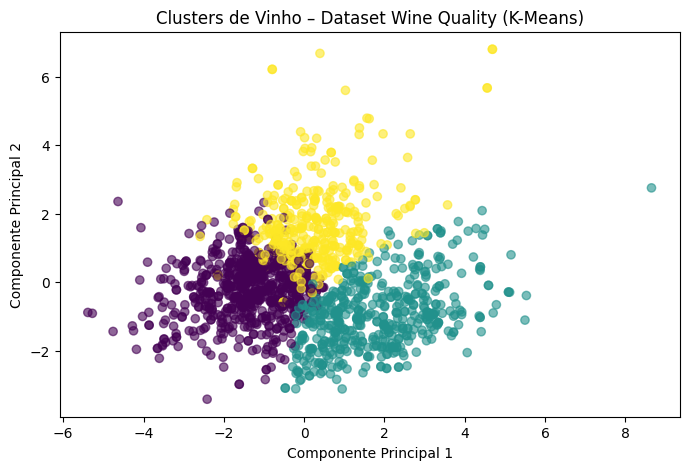

In [63]:
# Visualizar clusters
plt.figure(figsize=(8, 5)) 
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.title("Clusters de Vinho – Dataset Wine Quality (K-Means)") 
plt.xlabel("Componente Principal 1") 
plt.ylabel("Componente Principal 2") 
plt.show()

**Explicação**:
- O dataset possui 11 variáveis contínuas, como teor alcoólico, acidez, pH, etc.
- Aplicamos normalização para igualar a escala entre atributos.
- Usamos PCA para reduzir para 2 dimensões e facilitar a visualização.
- Este tipo de análise pode ser útil para segmentar vinhos com características semelhantes, por exemplo para posicionamento no mercado.

---

Exemplo 8 (continuação)

# Como Utilizar Modelos Treinados com Novos Dados

Depois de treinar um modelo de clustering, como K-Means ou GMM, é possível aplicar o modelo a novas observações para descobrir a que grupo elas pertencem. Abaixo está o procedimento passo a passo:

Passo 1: Suponha Um novo exemplo

In [64]:
# Exemplo: novo vinho com características medidas
novo_vinho = [[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]]

Passo 2: Normalizar com o mesmo scaler

In [65]:
# Normalizar usando o mesmo objeto scaler ajustado nos dados de treino
novo_vinho_scaled = scaler.transform(novo_vinho)
novo_vinho_scaled

array([[-0.52835961,  0.96187667, -1.39147228, -0.45321841, -0.24370669,
        -0.46619252, -0.37913269,  0.55827446,  1.28864292, -0.57920652,
        -0.96024611]])

Passo 3: Prever o cluster com K-Means

In [66]:
# Prever o cluster para o novo vinho
cluster = kmeans.predict(novo_vinho_scaled)
print(f"O novo vinho pertence ao cluster: {cluster[0]}")

O novo vinho pertence ao cluster: 0


GMM (Gaussian Mixture Models) - com probabilidades

In [67]:
# ADICIONADO com ajuda do ChatGPT - Não está no pdf
# Treina o GMM com os dados do vinho (11 features)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)  # X_scaled tem 11 features

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [68]:
# Prever com GMM
cluster = gmm.predict(novo_vinho_scaled)
probabilidades = gmm.predict_proba(novo_vinho_scaled)
print(f"O novo vinho pertence ao cluster: {cluster[0]}")
print(f"Probabilidades de pertencer a cada cluster: {probabilidades[0]}")

O novo vinho pertence ao cluster: 0
Probabilidades de pertencer a cada cluster: [9.91752802e-01 2.69802967e-05 8.22021731e-03]


Nota sobre DBSCAN


Modelos como DBSCAN não são generalizáveis para novos dados — isto é, não têm .predict(). Para aplicar DBSCAN a novos dados, seria necessário reajustar o modelo incluindo os novos pontos.

Considerações finais:
- Certifica-te sempre de que a ordem e escala das features do novo dado corresponde exatamente ao treino.
- Modelos como K-Means e GMM são adequados para uso contínuo com novos dados.
- Para produção, guarda o modelo e o scaler com joblib ou pickle.

In [69]:
# ADICIONADO com ajuda do ChatGPT - Não está no pdf

%pip install joblib --quiet

Note: you may need to restart the kernel to use updated packages.


In [70]:
import joblib

### Diferença entre `joblib` e `pickle` em Python

| Característica         | `pickle`                              | `joblib`                                      |
|------------------------|---------------------------------------|-----------------------------------------------|
| Faz parte da standard library? | Sim                                  | Não (precisa de `pip install joblib`)         |
| Otimizado para arrays grandes? | Não                                  | Sim (especialmente para NumPy e pandas)       |
| Uso típico             | Objetos Python simples                 | Modelos de machine learning, arrays grandes   |
| Compressão             | Não                                    | Sim (opcional, mas fácil de ativar)           |
| Velocidade             | Mais lento para arrays grandes         | Mais rápido para arrays grandes               |

**Resumo:**  
- Usa `pickle` para objetos Python simples.
- Prefere `joblib` para modelos do scikit-learn, arrays NumPy ou DataFrames grandes.

In [71]:
# Guardar
joblib.dump(kmeans, 'data/wine_modelo_kleans.pkl')
joblib.dump(scaler, 'data/wine_scaler.pkl')

# Reutilizar o modelo e scaler
kmeans = joblib.load('data/wine_modelo_kleans.pkl')
scaler = joblib.load('data/wine_scaler.pkl')

Na secção mostramos como utilizar os modelos de clustering para tarefas comuns no mundo real, com base em dados não rotulados. As aplicações seguem uma lógica passo a passo desde a preparação até à interpretação dos resultados.

Passo 1: Carregar e explorar os dados

In [72]:
import pandas as pd

In [73]:
# Carregar o dataset Wine Quality
df = pd.read_csv("data/winequality-red.csv", sep=',')
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.00000

Objetivo: Garantir que as variáveis estejam na mesma escala para não influenciar indevidamente as distâncias.

Passo 2: Preparar os dados

In [74]:
from sklearn.preprocessing import StandardScaler

# Selecionar apenas as variáveis preditoras (excluindo 'quality')
X = df.drop(columns=['quality'])

#Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Objectivo: Garantir que as variáveis estejam na mesma escala para não influenciar indevidamente as distâncias

Passo 3: Aplicar o modelo de clustering (K-Means)

In [75]:
from sklearn.cluster import KMeans

# Criar o modelo K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

Passo 4: Avaliar os resultados internamente

In [76]:
from sklearn.metrics import silhouette_score

sel_score = silhouette_score(X_scaled, labels)
print(f"Coeficiente de silhueta: {sel_score:.2f}")

Coeficiente de silhueta: 0.19


Objetivo: Avaliar quão bem os clusters estão definidos com valores próximos de 1 indicando melhor separação

Passo 5: Viasualizar os agrupamentos

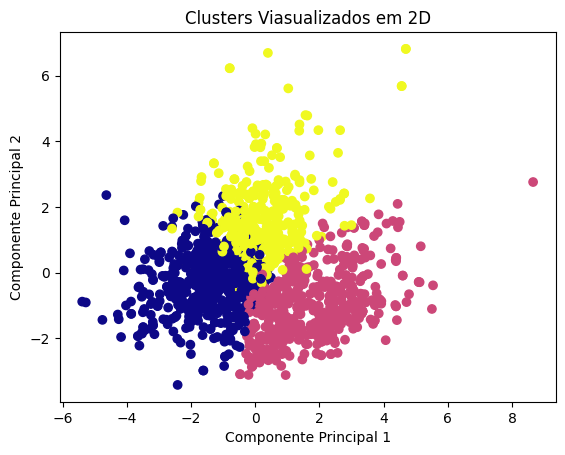

In [77]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar os clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters Viasualizados em 2D')
plt.show()

Passo 6: Relacionar com variáveis de interesse

In [78]:
#  Adicionar as etiquetas de cluster ao DataFrame

clustered_df = df.copy()
clustered_df['cluster'] = labels

# Analisar a média da qualidade por cluster
print(clustered_df.groupby('cluster')['quality'].mean())

cluster
0    5.552632
1    5.960159
2    5.362667
Name: quality, dtype: float64


Objetivo: Verificar se os clusters coincidem com níveis diferentes de qualidade mesmo sem o algoritmo saber disso previamente.

---

# Desafio Final: Agrupamento de Clientes com Dados Reais

**Objetivo**:  Aplicar  tudo  o  que  foi  aprendido  para  resolver  um  problema  real  de segmentação. 

**Enunciado**:
Foi-te entregue um dataset com informações anónimas sobre clientes de um retalhista online. O objetivo é **identificar grupos de clientes com comportamentos semelhantes** para personalizar estratégias de marketing.


**O que deves fazer**:
1. **Carrega o dataset clientes.csv** que contém colunas como: idade, salario_anual, frequencia_compra, gasto_mensal, tempo_como_cliente, entre outras. 
1. **Explora os dados**: verifica valores ausentes, tipos de variáveis, estatísticas.
1. **Normaliza as variáveis numéricas.**
1. **Aplica pelo menos dois métodos de clustering** (ex: K-Means e DBSCAN ou GMM).
1. **Visualiza os resultados com PCA**.
1. **Analisa os perfis de cada cluster** e escreve conclusões (ex: cluster 1 são jovens com baixo gasto, cluster 2 são clientes antigos e fiéis, etc)


**Entregáveis**:
* Código funcional com todos os passos 
* Gráficos de visualização 
* Tabela descritiva por cluster (médias ou contagens por grupo) 
* Texto interpretativo com sugestões práticas 

Este desafio simula uma situação comum em ciência de dados aplicada a negócios reais. Não há uma única resposta certa — o que importa é justificar bem cada decisão e interpretar os resultados de forma crítica.

In [79]:
# 0. Importar as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [80]:
# 1. Carregar o dataset
df = pd.read_csv('data/clientes.csv')
print(f'Shape: {df.shape}')
display(df.head())

Shape: (300, 6)


,idade,salario_anual,frequencia_compra,gasto_mensal,tempo_como_cliente,uso_aplicacao
0,56,28236,13,235,11,3
1,69,32167,12,186,12,5
2,46,41577,13,365,6,10
3,32,17222,14,385,14,4
4,60,31304,14,198,7,4


In [81]:
# 2. Exploração rápida
print('\nTipos de dados:')
print(df.dtypes)

print('\nValores ausentes por coluna:')
print(df.isna().sum())


Tipos de dados:
idade                 int64
salario_anual         int64
frequencia_compra     int64
gasto_mensal          int64
tempo_como_cliente    int64
uso_aplicacao         int64
dtype: object

Valores ausentes por coluna:
idade                 0
salario_anual         0
frequencia_compra     0
gasto_mensal          0
tempo_como_cliente    0
uso_aplicacao         0
dtype: int64


In [82]:
# 3. Pré-processamento
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols)
])

X = preprocessor.fit_transform(df)

In [83]:
# 4. Escolher k ótimo (K-Means) usando Silhouette
sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

best_k = max(sil_scores, key=sil_scores.get)
print('\nSilhouette scores:', sil_scores)
print(f'Melhor k: {best_k}')


Silhouette scores: {2: 0.12951487287652427, 3: 0.12307863453962789, 4: 0.13266313668511104, 5: 0.13024975524729368, 6: 0.13080955289415425, 7: 0.13936804982736659, 8: 0.13658059438927794}
Melhor k: 7


In [84]:
# 5. Clustering final
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X)

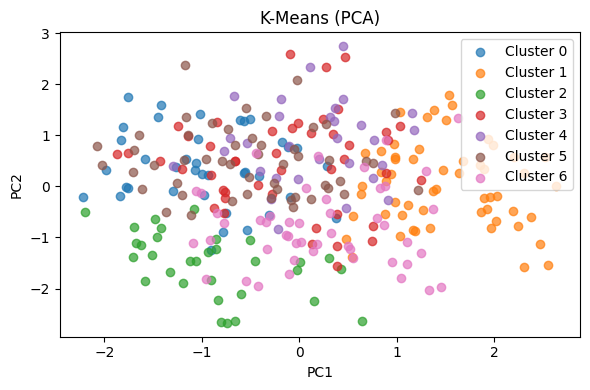

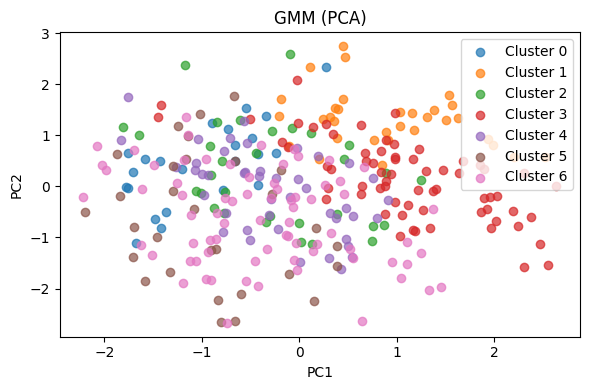

In [85]:
# 6. Visualização (PCA 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

def plot_clusters(labels, title):
    plt.figure(figsize=(6, 4))
    for lab in np.unique(labels):
        plt.scatter(
            X_pca[labels == lab, 0],
            X_pca[labels == lab, 1],
            label=f'Cluster {lab}',
            alpha=0.7
        )
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_clusters(kmeans_labels, 'K-Means (PCA)')
plot_clusters(gmm_labels,    'GMM (PCA)')

In [86]:
# 7. Perfil dos clusters (K-Means)
df_km = df.copy()
df_km['cluster'] = kmeans_labels

profile = (
    df_km.groupby('cluster')[numeric_cols]
    .mean()
    .round(2)
    .reset_index()
)

print('\nPerfil médio por cluster (K-Means):')
display(profile)


Perfil médio por cluster (K-Means):


,cluster,idade,salario_anual,frequencia_compra,gasto_mensal,tempo_como_cliente,uso_aplicacao
0,0,51.82,23081.76,14.55,325.74,4.16,4.74
1,1,54.64,35225.61,10.91,251.07,11.11,7.86
2,2,28.50,39747.19,9.66,283.06,3.00,4.94
3,3,53.13,36581.24,12.69,171.58,5.49,4.51
4,4,55.50,17363.53,9.67,285.17,9.20,3.20
5,5,30.25,28475.14,14.63,234.73,9.76,3.69
6,6,30.33,23066.17,11.71,244.98,7.31,8.67


In [87]:
# (Opcional) Salvar em CSV
# profile.to_csv('perfil_clusters.csv', index=False)

---
end of file